# Root Finding I: Bracketing Methods (solutions)

**Contents:** 1. the root-finding problem and brackets · 2. bisection · 3. false position · 4. when to stop · 5. comparing the methods · 6. summary · **Activity** (2 problems)

We use `numpy` for the numerical methods, `sympy` for exact answers to check them against, and `matplotlib` for the error plots. This notebook goes with the slides *Root Finding I: Bracketing Methods*.

In [1]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Math

print("sympy", sp.__version__, "| numpy", np.__version__)

sympy 1.14.0 | numpy 2.4.4


---
## 1. The root-finding problem and brackets

A **root** (or zero) of $f$ is a number $r$ with $f(r) = 0$. Any equation can be written this way: $x^2 = 2$ becomes $f(x) = x^2 - 2 = 0$, and $\cos x = x$ becomes $f(x) = \cos x - x = 0$. Most equations have **no formula** for the root, so we compute a sequence $c_1, c_2, \ldots \to r$ and stop when it is close enough.

**Intermediate Value Theorem.** If $f$ is **continuous** on $[a, b]$ and $f(a)$, $f(b)$ have **opposite signs**, then $f$ has at least one root in $(a, b)$. Such an interval is called a **bracket**.

| term | meaning | in code |
|---|---|---|
| bracket $[a, b]$ | $f$ continuous, $f(a)$ and $f(b)$ of opposite sign | `np.sign(f(a)) != np.sign(f(b))` |
| error $e_n$ | distance to the root, $\lvert c_n - r\rvert$ (needs the root!) | `abs(c - r)` |
| residual | how far $f$ is from $0$, $\lvert f(c_n)\rvert$ | `abs(f(c))` |
| function evaluation | one call of `f`; usually the expensive part | we count cost in these |

**What can go wrong.** Both conditions of the theorem matter, so **plot $f$ first**.

| example | sign change? | root? | what happens |
|---|---|---|---|
| $(x-1)^2$ on $[0, 2]$ | no | yes, $x = 1$ | no bracket: bracketing methods cannot find this root |
| $1/x$ on $[-1, 2]$ | yes | no | $f$ is not continuous; bisection "converges" to the jump at $0$ |
| $\sin(\pi x)$ on $[\tfrac12, \tfrac72]$ | yes | three: $1, 2, 3$ | the method finds **one** of them |

**Finding brackets on a grid.** Evaluate $f$ at $N + 1$ equally spaced points and keep every sub-interval where the sign changes. The function below does this; we use it again in the activity. (If a grid point hits a root exactly, its sign is $0$ and both neighbouring sub-intervals are reported; with a "random" $N$ this rarely happens.)

sin(pi x) on [0.5, 3.5]: [(0.929, 1.357), (1.786, 2.214), (2.643, 3.071)]
(x - 1)^2 on [0, 2]    : []   <- a root, but no sign change


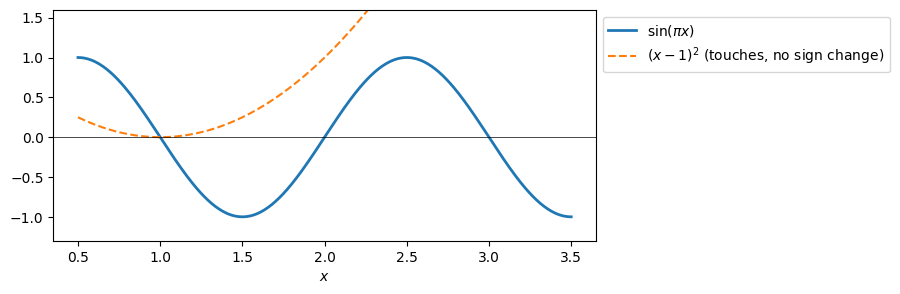

In [2]:
def find_brackets(f, a, b, N=100):
    # Return the list of sub-intervals [x_i, x_{i+1}] of [a, b] where f changes sign.
    xs = np.linspace(a, b, N + 1)
    s = np.sign(f(xs))
    return [(float(xs[i]), float(xs[i + 1])) for i in range(N) if s[i] != s[i + 1]]

def f_sin(t):
    return np.sin(np.pi * t)

def f_touch(t):
    return (t - 1)**2

print("sin(pi x) on [0.5, 3.5]:", [(round(l, 3), round(r, 3)) for l, r in find_brackets(f_sin, 0.5, 3.5, 7)])
print("(x - 1)^2 on [0, 2]    :", find_brackets(f_touch, 0, 2, 7), "  <- a root, but no sign change")

xs = np.linspace(0.5, 3.5, 400)
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(xs, f_sin(xs), lw=2, label=r"$\sin(\pi x)$")
ax.plot(xs, f_touch(xs), "--", label=r"$(x-1)^2$ (touches, no sign change)")
ax.axhline(0, color="k", lw=0.5)
ax.set_ylim(-1.3, 1.6); ax.set_xlabel("$x$"); ax.legend(loc="upper left", bbox_to_anchor=(1, 1))
plt.show()

---
## 2. The bisection method

Start with a bracket $[a, b]$ and repeat:

1. take the midpoint $c = a + \dfrac{b - a}{2}$;
2. if $f(a)$ and $f(c)$ have the **same** sign, the root is in $[c, b]$: set $a \leftarrow c$;
3. otherwise it is in $[a, c]$: set $b \leftarrow c$.

After every step $[a, b]$ is **still a bracket** and **half as wide**, so the midpoint $c_n$ of step $n$ satisfies

$$|c_n - r| \le \frac{b - a}{2^{\,n}}, \qquad \text{and} \qquad \frac{b-a}{2^{\,n}} \le \text{tol} \iff n \ge \log_2 \frac{b - a}{\text{tol}}.$$

| property | bisection |
|---|---|
| rate | linear, $\rho = \tfrac12$: one bit per step, one decimal digit every $\log_2 10 \approx 3.3$ steps |
| cost for tolerance tol | $n = \log_2(b-a) + \log_2(1/\text{tol})$ steps, so $O(\log(1/\text{tol}))$ function evaluations |
| error bound | known **before** we start, for every continuous $f$ |

**Floating point details in the code below:**
- `a + (b - a)/2` instead of `(a + b)/2`: always lands inside $[a, b]$.
- `np.sign(fc) == np.sign(fa)` instead of `fa * fc > 0`: the product can underflow to $0$.
- We keep `fa`, so each step needs only **one** new evaluation of $f$.

**Why we do not test `fc == 0`.** $f(c)$ is itself rounded, so an exact zero almost never happens: the test is too strong to be useful. If it does happen nothing breaks: $\operatorname{sign}(0) = 0 \ne \operatorname{sign}(f(a))$, so we keep $[a, c]$, which still contains the root $c$. Testing $|f(c)| < \text{tol}$ instead measures the **residual**, not the **error** (see Section 4). Bisection gives a true error bound for free, so we stop when $(b - a)/2 < \text{tol}$.

The function is the one from the slides, except that it also returns the list `hist` of all midpoints, so we can plot the errors.

In [3]:
def bisection(f, a, b, tol=1e-12, maxit=200):
    fa = f(a)
    if np.sign(fa) == np.sign(f(b)):
        raise ValueError("[a, b] is not a bracket: f(a) and f(b) have the same sign")
    hist = []
    for n in range(maxit):
        c = a + (b - a) / 2          # midpoint
        fc = f(c)                    # the only new f-evaluation
        hist.append(c)
        if (b - a) / 2 < tol:        # error bound |c - r| <= (b - a)/2 < tol
            break
        if np.sign(fc) == np.sign(fa):
            a, fa = c, fc            # root in [c, b]
        else:
            b = c                    # root in [a, c]
    return c, hist

def f_sq(t):
    return t**2 - 2

c, hist = bisection(f_sq, 1, 2, tol=1e-6)
print(f"{'n':>3} {'c_n':>12} {'|c_n - sqrt2|':>14} {'bound 2^-n':>11}")
for n, cn in enumerate(hist[:8], start=1):
    print(f"{n:>3} {cn:12.8f} {abs(cn - np.sqrt(2)):14.2e} {2.0**-n:11.2e}")
print(f"\nsteps used: {len(hist)},  predicted: ceil(log2(1/1e-6)) = {int(np.ceil(np.log2(1 / 1e-6)))}")
print(f"final c = {c:.10f},  error = {abs(c - np.sqrt(2)):.1e}")

  n          c_n  |c_n - sqrt2|  bound 2^-n
  1   1.50000000       8.58e-02    5.00e-01
  2   1.25000000       1.64e-01    2.50e-01
  3   1.37500000       3.92e-02    1.25e-01
  4   1.43750000       2.33e-02    6.25e-02
  5   1.40625000       7.96e-03    3.12e-02
  6   1.42187500       7.66e-03    1.56e-02
  7   1.41406250       1.51e-04    7.81e-03
  8   1.41796875       3.76e-03    3.91e-03

steps used: 20,  predicted: ceil(log2(1/1e-6)) = 20
final c = 1.4142141342,  error = 5.7e-07


---
## 3. The false position method

Bisection ignores the **values** of $f$: only their signs are used. False position replaces $f$ by the **secant line** through $(a, f(a))$ and $(b, f(b))$ and takes its zero:

$$c = b - f(b)\,\frac{b - a}{f(b) - f(a)} = \frac{a\,f(b) - b\,f(a)}{f(b) - f(a)}.$$

Then it keeps the half with the sign change, exactly as bisection does, so $[a, b]$ is **still a bracket**.

| property | false position |
|---|---|
| rate | linear, but $\rho$ depends on $f$ (often much better than $\tfrac12$, sometimes much worse) |
| error bound in advance | no |
| bracket width $\to 0$ | **not always**: one endpoint can get stuck |
| stopping test | the bracket width may never get small, so we stop when the **step** $\lvert c_n - c_{n-1}\rvert$ is below tol |

Compared with `bisection`, only the line that computes `c` changes, and we now also keep `fb`.

In [4]:
def false_position(f, a, b, tol=1e-12, maxit=200):
    fa, fb = f(a), f(b)
    if np.sign(fa) == np.sign(fb):
        raise ValueError("[a, b] is not a bracket: f(a) and f(b) have the same sign")
    hist = []
    c_old = np.inf
    for n in range(maxit):
        c = b - fb * (b - a) / (fb - fa)   # zero of the secant line
        fc = f(c)
        hist.append(c)
        if abs(c - c_old) < tol:            # step size test
            break
        c_old = c
        if np.sign(fc) == np.sign(fa):
            a, fa = c, fc                   # root in [c, b]
        else:
            b, fb = c, fc                   # root in [a, c]
    return c, hist

c, hist = false_position(f_sq, 1, 2, tol=1e-6)
print(f"{'n':>3} {'c_n':>12} {'|c_n - sqrt2|':>14} {'ratio e_n/e_(n-1)':>18}")
e = [abs(cn - np.sqrt(2)) for cn in hist]
for n in range(min(8, len(hist))):
    ratio = f"{e[n] / e[n - 1]:18.3f}" if n > 0 else ""
    print(f"{n + 1:>3} {hist[n]:12.8f} {e[n]:14.2e} {ratio}")
print("\nThe right endpoint b = 2 is never replaced: the bracket shrinks to [sqrt2, 2], not to a point.")

  n          c_n  |c_n - sqrt2|  ratio e_n/e_(n-1)
  1   1.33333333       8.09e-02 
  2   1.40000000       1.42e-02              0.176
  3   1.41176471       2.45e-03              0.172
  4   1.41379310       4.20e-04              0.172
  5   1.41414141       7.21e-05              0.172
  6   1.41420118       1.24e-05              0.172
  7   1.41421144       2.12e-06              0.172
  8   1.41421320       3.64e-07              0.172

The right endpoint b = 2 is never replaced: the bracket shrinks to [sqrt2, 2], not to a point.


---
## 4. When do we stop?

| test | formula | good | bad |
|---|---|---|---|
| bracket width | $(b - a)/2 < \text{tol}$ | a **true error bound** for bisection | may never trigger for false position |
| step size | $\lvert c_n - c_{n-1}\rvert < \text{tol}$ | works for every method | not a guarantee |
| residual | $\lvert f(c_n)\rvert < \text{tol}_f$ | cheap | depends on the **scale** of $f$; small residual $\ne$ small error |
| exact zero | $f(c_n) = 0$ | | almost never happens in floating point |

**Always** add a maximum number of iterations, and keep tol well above machine epsilon times $|r|$: below $\approx 10^{-16}|r|$ there are no floats left between $a$ and $b$.

The cell below shows why the residual is a poor stopping test: a flat function has a tiny residual far from its root, and a steep one has a large residual very close to it.

In [5]:
def flat(t):
    return (t - 1)**10          # root r = 1, very flat

def steep(t):
    return 1e10 * (t - 1)       # root r = 1, very steep

print(f"flat : c = 1.1,      error = {0.1:.0e},  residual |f(c)| = {abs(flat(1.1)):.0e}   <- 'converged' by the residual test")
print(f"steep: c = 1 + 1e-8, error = {1e-8:.0e},  residual |f(c)| = {abs(steep(1 + 1e-8)):.0e}   <- 'not converged'")
print("\nfloating point floor: np.spacing(1.0) =", np.spacing(1.0))

flat : c = 1.1,      error = 1e-01,  residual |f(c)| = 1e-10   <- 'converged' by the residual test
steep: c = 1 + 1e-8, error = 1e-08,  residual |f(c)| = 1e+02   <- 'not converged'

floating point floor: np.spacing(1.0) = 2.220446049250313e-16


---
## 5. Comparing the methods: plot the error on a log scale

As in the convergence lecture, plot $e_n = |c_n - r|$ with `plt.semilogy`: a **straight line** means linear convergence, and its slope gives $\rho$.

Two test problems with known roots: $x^2 - 2$ on $[1, 2]$ ($r = \sqrt2$) and $x^{10} - 1$ on $[0, 1.3]$ ($r = 1$). On the second one, false position is **much slower** than bisection: $f$ is flat on the left and steep on the right, so every secant line crosses the axis far to the left of $r$ and $b = 1.3$ is never replaced.

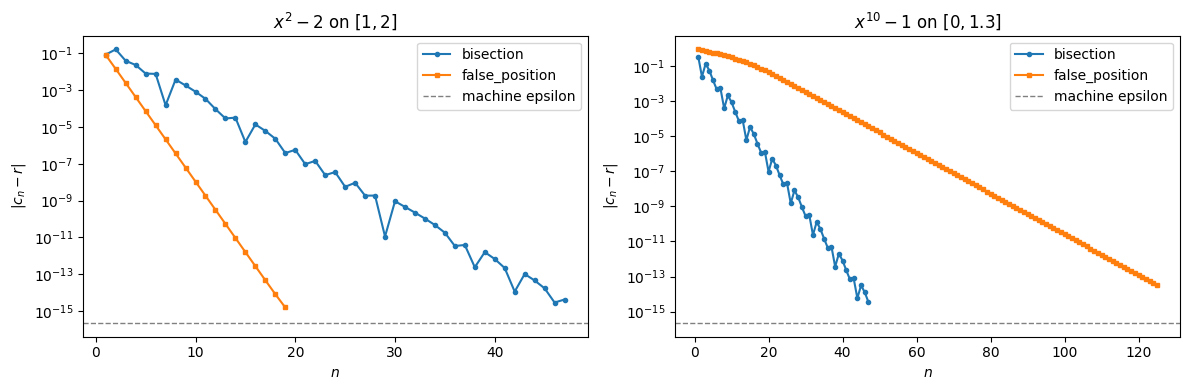

In [6]:
def f_ten(t):
    return t**10 - 1

problems = [("$x^2 - 2$ on $[1, 2]$", f_sq, 1, 2, np.sqrt(2)),
            ("$x^{10} - 1$ on $[0, 1.3]$", f_ten, 0, 1.3, 1.0)]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (title, f, a, b, r) in zip(axes, problems):
    for method, style in [(bisection, "o-"), (false_position, "s-")]:
        _, hist = method(f, a, b, tol=1e-14, maxit=500)
        err = np.maximum(np.abs(np.array(hist) - r), 1e-17)     # avoid log(0)
        ax.semilogy(np.arange(1, len(err) + 1), err, style, ms=3, label=method.__name__)
    ax.axhline(np.finfo(float).eps, color="gray", ls="--", lw=1, label="machine epsilon")
    ax.set_title(title); ax.set_xlabel("$n$"); ax.set_ylabel(r"$|c_n - r|$"); ax.legend()
plt.tight_layout()
plt.show()

---
## 6. Summary

| | bisection | false position |
|---|---|---|
| new point $c$ | midpoint $a + (b-a)/2$ | zero of the secant line $\dfrac{a f(b) - b f(a)}{f(b) - f(a)}$ |
| needs a bracket / always converges | yes / yes | yes / yes |
| rate | linear, $\rho = \tfrac12$ | linear, $\rho$ depends on $f$ |
| error bound in advance | $(b - a)/2^n$ | none |
| bracket width $\to 0$ | yes | not always (stuck endpoint) |
| natural stopping test | $(b - a)/2 < \text{tol}$ | $\lvert c_n - c_{n-1}\rvert < \text{tol}$ |
| $f$-evaluations per step | 1 | 1 |

**The Illinois method** (last slide) fixes the stuck endpoint of false position with one extra rule: if the same endpoint is kept in **two steps in a row**, halve its stored function value before the next secant step. Halving changes the *size* of $f(b)$, not its *sign*, so $[a, b]$ stays a bracket. You implement it in Problem 2.

---
# Activity

Two problems. **Problem 1** finds the same roots twice, exactly with SymPy's `solveset` and numerically with `bisection`. **Problem 2** asks you to implement the **Illinois method** and race it against bisection and false position. Each step says **what your code should do**. Write the code in the empty cell, then run the **check** cell: it prints your results next to the **expected** ones. Open a **Hint** box only when you are stuck.

**About `None` and `pass`:** replace `None` by your answer, and delete `pass` once you write the body of a function.

**Useful commands for this activity**

| you want to ... | command |
|---|---|
| all roots of $e = 0$ in $[a, b]$, exactly | `sp.solveset(e, x, domain=sp.Interval(a, b))` |
| add to a list / list of lists | `L = []`, `L.append(v)`; `M[k][j]` is entry `j` of row `k` |
| the methods | `bisection(f, a, b, tol, maxit)`, `false_position(...)`, your `illinois(...)`: each returns `(c, hist)` |
| bracket test | `np.sign(fa) == np.sign(fb)` |

---
## Problem 1: exact roots with `solveset`, numerical roots with bisection

**Goal:** use the bracket as the **domain** of `sp.solveset`, so SymPy returns exactly the roots inside $[a, b]$; then run `bisection` on the same brackets and check its error and its number of steps against the theory.

**What you will see:** SymPy finds $\sqrt2$, $1$ and a cubic formula exactly, but for $\cos x = x$ it can only say "the set of $x$ in $[0, 1]$ with $\cos x - x = 0$": that is why we need numerical methods. Bisection needs exactly the number of steps the formula $\lceil \log_2((b-a)/\text{tol}) \rceil$ predicts, whatever the function.

Run the cell below to create the test problems (do not change it). Problem number `k` (counting from $0$) is stored in position `k` of five lists: its name `names[k]`, its expression `exprs[k]`, its bracket `a_list[k]`, `b_list[k]` (exact numbers, for SymPy), and its NumPy function `funcs[k]`, ready for `bisection` (use it with `float(a_list[k])`, `float(b_list[k])`). The list `r_ref` holds an accurate value of each root, computed by SymPy with extra digits; we use it to measure errors.

In [7]:
x = sp.Symbol('x', real=True)
names  = ["x^2 - 2", "x^10 - 1", "x^3 - x - 2", "cos x - x"]
exprs  = [x**2 - 2, x**10 - 1, x**3 - x - 2, sp.cos(x) - x]
a_list = [1, 0, 1, 0]
b_list = [2, sp.Rational(13, 10), 2, 1]
funcs = []
r_ref = []
for k in range(len(exprs)):
    funcs.append(sp.lambdify(x, exprs[k], 'numpy'))
    r_ref.append(float(sp.nsolve(exprs[k], x, (a_list[k], b_list[k]), solver='bisect')))
print("reference roots:", r_ref)

reference roots: [1.4142135623730951, 1.0, 1.5213797068045676, 0.7390851332151607]


### Step 1: `solveset` on each bracket

Write code that:

1. builds a list `exact1` with one entry per test problem: entry `k` is `sp.solveset(exprs[k], x, domain=sp.Interval(a_list[k], b_list[k]))`;
2. displays each name together with its solution set.

<details><summary><b>Hint</b></summary>

- Before the loop, start with an empty list: `exact1 = []`.
- Loop over the problem numbers with `for k in range(len(exprs)):`.
- Inside the loop: make the interval from `a_list[k]` and `b_list[k]` with `sp.Interval`, call `sp.solveset` with the expression of problem `k` and `domain=` that interval, and `append` the result to `exact1`.
- To show the results, loop again over `k` and use `print(names[k])` and `display(...)`.

```python
exact1 = []
for k in range(len(exprs)):
    S = sp.solveset(..., x, domain=...)
    ...
```

</details>

In [8]:
exact1 = []
for k in range(len(exprs)):
    exact1.append(sp.solveset(exprs[k], x, domain=sp.Interval(a_list[k], b_list[k])))
for k in range(len(exact1)):
    print(names[k], ":")
    display(exact1[k])

x^2 - 2 :


{sqrt(2)}

x^10 - 1 :


{1}

x^3 - x - 2 :


{1/(3*(sqrt(78)/9 + 1)**(1/3)) + (sqrt(78)/9 + 1)**(1/3)}

cos x - x :


ConditionSet(x, Eq(-x + cos(x), 0), Interval(0, 1))

In [9]:
# check: compare your results with the expected ones
if exact1 is None:
    print("exact1 is still None: write the code in the cell above, then run this cell again.")
else:
    print("x^2 - 2     :", exact1[0], "   (expected: {sqrt(2)})")
    print("x^10 - 1    :", exact1[1], "   (expected: {1}; the root -1 is outside the bracket)")
    print("x^3 - x - 2 :", type(exact1[2]).__name__, "   (expected: FiniteSet, one root given by a cube-root formula)")
    print("cos x - x   :", type(exact1[3]).__name__, "   (expected: ConditionSet, SymPy cannot solve it exactly)")

x^2 - 2     : {sqrt(2)}    (expected: {sqrt(2)})
x^10 - 1    : {1}    (expected: {1}; the root -1 is outside the bracket)
x^3 - x - 2 : FiniteSet    (expected: FiniteSet, one root given by a cube-root formula)
cos x - x   : ConditionSet    (expected: ConditionSet, SymPy cannot solve it exactly)


### Step 2: bisection on the same brackets

With `tol = 1e-10`, write code that, for every test problem `k`,

1. runs `c, hist = bisection(funcs[k], a, b, tol=tol)` with `a = float(a_list[k])`, `b = float(b_list[k])`;
2. appends to the list `steps1` the number of steps `len(hist)`, and to the list `err1` the error `abs(c - r_ref[k])`;
3. prints one line per problem with these two numbers.

The check cell compares your number of steps with the prediction $\lceil \log_2((b-a)/\text{tol}) \rceil$.

<details><summary><b>Hint</b></summary>

- Same pattern as Step 1, but with **two** empty lists before the loop.
- `funcs[k]` is a NumPy function, so pass it the end points as floats: `float(a_list[k])`, `float(b_list[k])`.
- `bisection` returns **two** things, so receive them as `c, hist = bisection(...)`. Do not forget `tol=tol`.
- The number of steps is the **length** of `hist`; the error compares `c` with the reference root of the **same** problem `k`.

```python
steps1, err1 = [], []
for k in range(len(funcs)):
    a, b = ..., ...
    c, hist = bisection(...)
    steps1.append(...)
    err1.append(...)
```

</details>

In [10]:
tol = 1e-10
steps1, err1 = [], []
for k in range(len(funcs)):
    a, b = float(a_list[k]), float(b_list[k])
    c, hist = bisection(funcs[k], a, b, tol=tol)
    steps1.append(len(hist))
    err1.append(abs(c - r_ref[k]))
    print(names[k], ": steps =", steps1[k], ", error =", err1[k])

x^2 - 2 : steps = 34 , error = 4.705502654189786e-11
x^10 - 1 : steps = 34 , error = 5.238676159535771e-11
x^3 - x - 2 : steps = 34 , error = 5.2692739060944405e-11
cos x - x : steps = 34 , error = 3.051980890234063e-11


In [11]:
# check: compare your results with the expected ones
if steps1 is None or err1 is None:
    print("Something is still None: write the code in the cell above, then run this cell again.")
else:
    for k in range(len(steps1)):
        a, b = float(a_list[k]), float(b_list[k])
        predicted = int(np.ceil(np.log2((b - a) / 1e-10)))
        print(f"{names[k]:>12}: steps = {steps1[k]}, predicted = {predicted}, error = {err1[k]:.1e}   (expected: 34, 34, error below 1e-10)")

     x^2 - 2: steps = 34, predicted = 34, error = 4.7e-11   (expected: 34, 34, error below 1e-10)
    x^10 - 1: steps = 34, predicted = 34, error = 5.2e-11   (expected: 34, 34, error below 1e-10)
 x^3 - x - 2: steps = 34, predicted = 34, error = 5.3e-11   (expected: 34, 34, error below 1e-10)
   cos x - x: steps = 34, predicted = 34, error = 3.1e-11   (expected: 34, 34, error below 1e-10)


**Questions:**
1. Why did we write the bracket of $x^{10} - 1$ as `sp.Rational(13, 10)` and not `1.3`? Try `sp.Interval(0, 1.3)` and look at the type of the end point.
2. The four functions are very different, yet bisection takes the same number of steps for all of them. Why?

---
## Problem 2: the Illinois method and the race

**Goal:** implement the Illinois method and compare `bisection`, `false_position` and your `illinois` on the four test problems of Problem 1, using the reference roots `r_ref` to measure the true errors.

**What you will see:** one extra rule turns the slow, stuck false position into a method that needs only a handful of steps. False position is fast on some problems and very slow on $x^{10} - 1$; Illinois is never slow; bisection is never fast, but always predictable.

### Step 1: implement `illinois`

Write a function `illinois(f, a, b, tol=1e-12, maxit=200)` with the same inputs and outputs as `false_position`: it **returns** `(c, hist)`, the last point and the list of all points $c_1, c_2, \ldots$

**Algorithm.** Copy `false_position` from Section 3 and add a variable `side = 0` before the loop: it remembers which endpoint was replaced in the previous step. Then change only the end of the loop:

1. if $f(c)$ has the sign of $f(a)$: replace $a$ (`a, fa = c, fc`); if `side == +1` (we also replaced $a$ last time, so $b$ is kept twice), halve `fb`; set `side = +1`;
2. otherwise: replace $b$ (`b, fb = c, fc`); if `side == -1`, halve `fa`; set `side = -1`.

<details><summary><b>Hint</b></summary>

- Everything in `false_position` up to and including the line `c_old = c` stays **unchanged**; only the `if`/`else` at the end of the loop gets new lines.
- `side = 0` goes **before** the `for` loop, next to `c_old = np.inf`, so that it is remembered from one step to the next.
- In each branch, first replace the endpoint, then **test** `side` (it still holds the value from the previous step), and only then **update** `side`. If you update it first, the test always succeeds.
- You halve the stored value of the endpoint that was **kept**, never the one you just replaced.
- The `else` branch is the mirror image of the `if` branch: swap the roles of `a` and `b`, and of `+1` and `-1`.

```python
        if np.sign(fc) == np.sign(fa):   # a is replaced by c
            a, fa = c, fc
            if side == ...:              # a was also replaced in the previous step, so b is kept twice
                ...                      # halve the stored value f(b)
            side = ...
        else:                            # b is replaced by c
            ...
```

**Debugging:** if the check shows different first four points, add `print(n, a, b, side)` inside the loop and follow the first few steps on $x^2 - 2$ by hand.

</details>

In [12]:
def illinois(f, a, b, tol=1e-12, maxit=200):
    fa, fb = f(a), f(b)
    if np.sign(fa) == np.sign(fb):
        raise ValueError("[a, b] is not a bracket: f(a) and f(b) have the same sign")
    hist = []
    c_old = np.inf
    side = 0                                # which endpoint was replaced last: +1 = a, -1 = b
    for n in range(maxit):
        c = b - fb * (b - a) / (fb - fa)    # zero of the secant line
        fc = f(c)
        hist.append(c)
        if abs(c - c_old) < tol:
            break
        c_old = c
        if np.sign(fc) == np.sign(fa):
            a, fa = c, fc
            if side == +1:
                fb = fb / 2                 # b kept twice in a row
            side = +1
        else:
            b, fb = c, fc
            if side == -1:
                fa = fa / 2                 # a kept twice in a row
            side = -1
    return c, hist

In [13]:
# check: compare your results with the expected ones (f_sq(t) = t**2 - 2 is defined in Section 2)
out = illinois(f_sq, 1, 2)
if out is None:
    print("illinois returned None: finish the function (and delete the line `pass`), then run this cell again.")
else:
    c, hist = out
    print("c          =", repr(c), "   (expected: 1.414213562373095 or ...0951)")
    print("steps      =", len(hist), "   (expected: about 8; false position needs 17 with the same tol)")
    print("first four =", [round(v, 6) for v in hist[:4]], "   (expected: [1.333333, 1.4, 1.423077, 1.414169])")

c          = 1.414213562373095    (expected: 1.414213562373095 or ...0951)
steps      = 8    (expected: about 8; false position needs 17 with the same tol)
first four = [1.333333, 1.4, 1.423077, 1.414169]    (expected: [1.333333, 1.4, 1.423077, 1.414169])


### Step 2: the race, steps to reach an error of $10^{-6}$

Run the next cell (do not change it). It collects the three methods, and their names, in two lists: in Python a function can be stored in a list like any other value, and `methods[j](f, a, b)` calls method number `j`. It also defines `steps_to(hist, r, tol)`, which returns the first $n$ (counting from $1$) with $|c_n - r| < \text{tol}$.

In [14]:
methods = [bisection, false_position, illinois]
method_names = ["bisection", "false position", "Illinois"]

def steps_to(hist, r, tol):
    for n in range(len(hist)):
        if abs(hist[n] - r) < tol:
            return n + 1
    return None

Build a list of lists `steps3`: entry `steps3[k]` is the list `[steps for bisection, steps for false position, steps for Illinois]` for test problem `k`, where each number is `steps_to(hist, r_ref[k], 1e-6)` and `hist` comes from running the method on `funcs[k]`, `float(a_list[k])`, `float(b_list[k])` with `tol=1e-14, maxit=500`. Print one line per problem.

<details><summary><b>Hint</b></summary>

- You need **two** loops, one inside the other: the outer loop over the problems `k`, the inner loop over the methods `j`.
- Before the inner loop, start an empty list `row = []`; after the inner loop, append the whole `row` to `steps3`.
- `methods[j]` is a function: call it like `bisection`, with `funcs[k]`, the float end points, `tol=1e-14` and `maxit=500`. It returns `c, hist`.
- Each entry of `row` is `steps_to(...)` applied to that `hist`, the reference root of problem `k`, and the tolerance `1e-6`.

```python
steps3 = []
for k in range(len(funcs)):
    a, b = float(a_list[k]), float(b_list[k])
    row = []
    for j in range(len(methods)):
        ...
        ...
    steps3.append(row)
    print(names[k], row)
```

</details>

In [15]:
steps3 = []
for k in range(len(funcs)):
    a, b = float(a_list[k]), float(b_list[k])
    row = []
    for j in range(len(methods)):
        c, hist = methods[j](funcs[k], a, b, tol=1e-14, maxit=500)
        row.append(steps_to(hist, r_ref[k], 1e-6))
    steps3.append(row)
    print(names[k], row)

x^2 - 2 [19, 8, 5]
x^10 - 1 [20, 61, 13]
x^3 - x - 2 [19, 11, 7]
cos x - x [19, 5, 5]


In [16]:
# check: compare your results with the expected ones
if steps3 is None:
    print("steps3 is still None: write the code in the cell above, then run this cell again.")
else:
    expected = [[19, 8, 5], [20, 61, 13], [19, 11, 7], [19, 5, 5]]
    for k in range(len(expected)):
        print(f"{names[k]:>12}: [bisection, false position, Illinois] = {steps3[k]}   (expected: {expected[k]})")

     x^2 - 2: [bisection, false position, Illinois] = [19, 8, 5]   (expected: [19, 8, 5])
    x^10 - 1: [bisection, false position, Illinois] = [20, 61, 13]   (expected: [20, 61, 13])
 x^3 - x - 2: [bisection, false position, Illinois] = [19, 11, 7]   (expected: [19, 11, 7])
   cos x - x: [bisection, false position, Illinois] = [19, 5, 5]   (expected: [19, 5, 5])


### Step 3: look at the errors

Run the cell below (do not change it): it plots the error $|c_n - r|$ of the three methods on the four test problems with `semilogy`, using your `illinois`.

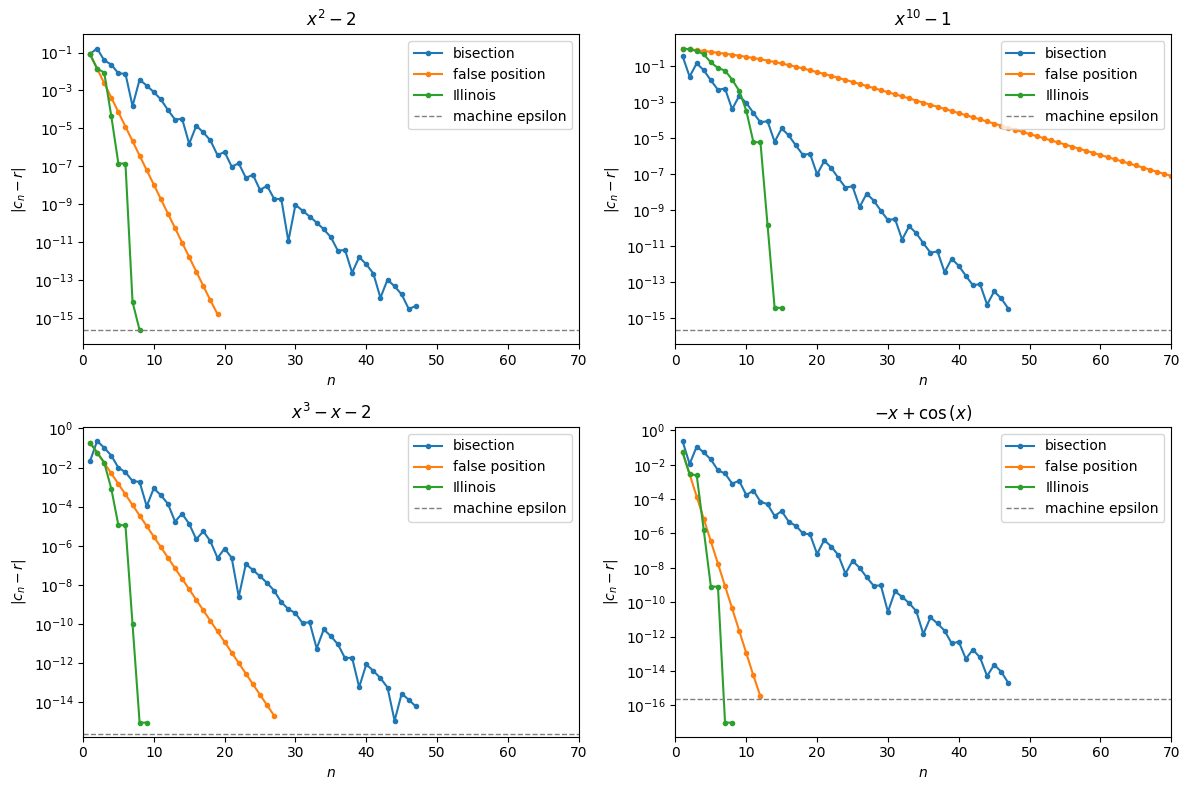

In [17]:
if illinois(f_sq, 1, 2) is None:
    print("illinois returned None: finish Step 1 first, then run this cell again.")
else:
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    for k in range(len(funcs)):
        ax = axes.flat[k]
        a, b = float(a_list[k]), float(b_list[k])
        for j in range(len(methods)):
            c, hist = methods[j](funcs[k], a, b, tol=1e-14, maxit=500)
            err = np.maximum(np.abs(np.array(hist) - r_ref[k]), 1e-17)
            ax.semilogy(np.arange(1, len(err) + 1), err, "o-", ms=3, label=method_names[j])
        ax.axhline(np.finfo(float).eps, color="gray", ls="--", lw=1, label="machine epsilon")
        ax.set_xlim(0, 70); ax.set_title(f"${sp.latex(exprs[k])}$"); ax.set_xlabel("$n$"); ax.set_ylabel(r"$|c_n - r|$"); ax.legend()
    plt.tight_layout()
    plt.show()

**Questions:**
1. Halving `fb` changes the secant line. Why does $[a, b]$ still contain a root afterwards?
2. The bisection and false position curves are (roughly) straight lines; the Illinois curve bends down. What does that say about the rates (look back at the convergence lecture)?
3. You need the root of a new function and know nothing about it except a bracket. Which method would you choose, and why?